In [1]:
from sklearn.datasets import load_iris

data = load_iris()

x = data.data
y = data.target

print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [2]:
print("Feature names:")
print(data.feature_names)

print("\nTarget names:")
print(data.target_names)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [3]:
import pandas as pd

df = pd.DataFrame(x, columns=data.feature_names)
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [5]:
x = df.drop("target", axis=1)
y = df["target"]

print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (120, 4)
X_test : (30, 4)
y_train: (120,)
y_test : (30,)


In [8]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

print(model)

DecisionTreeClassifier(max_depth=3, random_state=42)


In [9]:
model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [15]:
y_train_pred = model.predict(x_train)
print(y_train_pred[:10])

y_pred = model.predict(x_test)
print(y_pred[:10])

[0 2 1 0 1 2 1 2 2 2]
[0 2 1 1 0 1 0 0 2 1]


In [16]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", test_accuracy)

Train Accuracy: 0.9833333333333333
Test Accuracy : 0.9666666666666667


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [20]:
importances = model.feature_importances_

for feature, importance in zip(x.columns, importances):
    print(f"{feature}: {importance:.4f}")

sepal length (cm): 0.0000
sepal width (cm): 0.0000
petal length (cm): 0.5791
petal width (cm): 0.4209


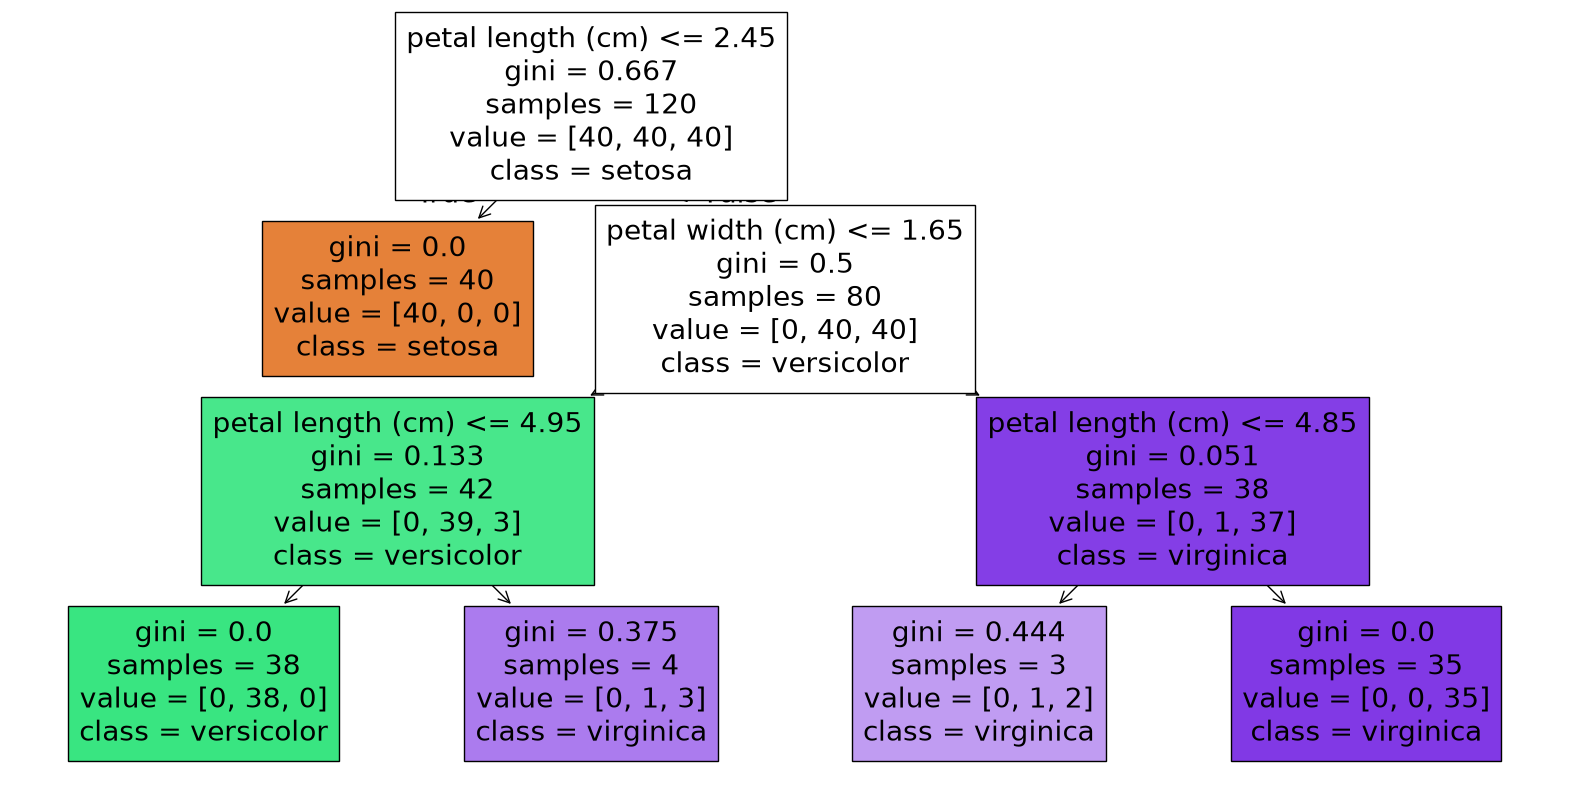

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=data.target_names,
    filled=True
)

plt.show()

In [23]:
print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Tree depth: 3
Number of leaves: 5


In [24]:
print("Number of nodes:", model.tree_.node_count)

Number of nodes: 9


In [25]:
new_sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_sample)

print("Predicted class:", prediction)
print("Predicted species:", data.target_names[prediction[0]])

Predicted class: [0]
Predicted species: setosa


Y:\Python\AI ML\Month 2\week 6-Classic ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [28]:
depths = [1, 2, 3, 4, 5, 10]

for depth in depths:
    model_temp = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model_temp.fit(x_train, y_train)

    train_pred = model_temp.predict(x_train)
    test_pred = model_temp.predict(x_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(
        f"Depth={depth:<2} | "
        f"Train={train_acc:.3f} | "
        f"Test={test_acc:.3f}"
    )

Depth=1  | Train=0.667 | Test=0.667
Depth=2  | Train=0.967 | Test=0.933
Depth=3  | Train=0.983 | Test=0.967
Depth=4  | Train=0.992 | Test=0.933
Depth=5  | Train=1.000 | Test=0.933
Depth=10 | Train=1.000 | Test=0.933


# 🌳 Decision Trees — Complete Notes

## 1. What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm that makes predictions by learning a sequence of **if–else rules** from the data.

Example:

```text
Petal length <= 2.45?
       /       \
     Yes        No
     ↓           ↓
  Setosa    Petal width <= 1.75?
                /      \
              Yes       No
              ↓          ↓
         Versicolor   Virginica
```

The tree recursively divides the dataset into smaller groups until it reaches a prediction.

### Why use Decision Trees?

Decision Trees are useful because they:

* Handle **classification and regression**
* Capture **nonlinear relationships**
* Naturally capture **feature interactions**
* Require **no feature scaling**
* Are relatively easy to interpret
* Produce human-readable decision rules

---

# 2. Tree Structure

A Decision Tree contains:

| Term       | Meaning                                           |
| ---------- | ------------------------------------------------- |
| **Root**   | First/top decision node                           |
| **Node**   | A decision point                                  |
| **Branch** | Result/path of a decision                         |
| **Leaf**   | Final prediction                                  |
| **Split**  | Division of data based on a feature and threshold |

Example:

```text
             Root
        Age <= 30?
         /       \
       Yes        No
       /           \
    Node           Leaf
 Income > 50K     Class 1
   /     \
 Leaf    Leaf
```

The tree is essentially a collection of learned **if/else rules**.

---

# 3. How Does a Tree Split Data?

Suppose we have:

```text
Age    Income    Buy?
22     20K       No
25     25K       No
35     60K       Yes
40     70K       Yes
```

The tree may test:

```text
Age <= 30?
```

Then:

```text
Left child:
Age <= 30 → No, No

Right child:
Age > 30 → Yes, Yes
```

The children are now **pure**.

The tree searches through possible:

```text
Feature + Threshold
```

combinations and chooses a split that makes the resulting groups as **pure** as possible.

---

# 4. Gini Impurity ⭐⭐⭐

Gini impurity measures how **mixed** the classes are inside a node.

$$
Gini = 1-\sum_{k=1}^{K}p_k^2
$$

where:

* \(p_k\) = proportion of class \(k\)
* \(K\) = number of classes

### Binary example

Suppose:

```text
10 samples
10 Yes
0 No
```

$$
Gini=1-(1)^2-(0)^2=0
$$

So:

> **Pure node → Gini = 0**

---

### 50/50 node

```text
10 samples
5 Yes
5 No
```

$$
Gini=1-(0.5)^2-(0.5)^2
$$

$$
Gini=0.5
$$

For binary classification, **0.5 is the maximum Gini impurity**.

### Remember

```text
Lower Gini → more pure
Gini = 0   → perfectly pure
```

---

# 5. Weighted Gini Impurity

When a split produces two children, we calculate the **weighted average** of their impurities.

$$
Gini_{split}
=
\frac{N_L}{N}Gini_L+
\frac{N_R}{N}Gini_R
$$

where:

* \(N\) = total samples
* \(N_L\) = samples in left child
* \(N_R\) = samples in right child

The weighting matters because a child containing 90% of the data should have more influence than one containing only 10%.

### Split selection

With Gini:

> **Choose the split with the lowest weighted Gini impurity.**

---

# 6. Entropy ⭐⭐⭐

Entropy measures the **uncertainty/impurity** in a node.

$$
Entropy=-\sum_{k=1}^{K}p_k\log_2(p_k)
$$

### Pure node

```text
100% Class A
0% Class B
```

$$
Entropy=0
$$

### 50/50 node

```text
50% Class A
50% Class B
```

$$
Entropy=1
$$

For binary classification:

```text
Pure → Entropy = 0
50/50 → Entropy = 1
```

Therefore:

> **Lower entropy → purer node**

---

# 7. Weighted Entropy ⭐⭐⭐

Suppose:

```text
Parent = 10 samples

Left child  = 8 samples
Entropy     = 0

Right child = 2 samples
Entropy     = 1
```

Weights:

$$
\frac{8}{10}=0.8
$$

$$
\frac{2}{10}=0.2
$$

Weighted entropy:

$$
H_{children}
=
0.8(0)+0.2(1)
$$

$$
=0.2
$$

### Key idea

> **Weighted entropy = each child's entropy × its fraction of the original data, then add them.**

---

# 8. Information Gain ⭐⭐⭐

Information Gain measures how much uncertainty is reduced after a split.

$$
IG=H(parent)-H(children)
$$

Example:

```text
Parent entropy = 0.9
Weighted child entropy = 0.2
```

Therefore:

$$
IG=0.9-0.2=0.7
$$

Higher Information Gain means a better split.

### Split selection

With entropy:

> **Choose the split with the highest Information Gain.**

Equivalent idea:

> Choose the split producing the lowest weighted child entropy.

---

# 9. Gini vs Entropy

Both measure impurity.

|                          | Gini                | Entropy                 |
| ------------------------ | ------------------- | ----------------------- |
| Measures                 | Impurity            | Uncertainty             |
| Pure node                | 0                   | 0                       |
| Binary maximum           | 0.5                 | 1                       |
| Better split             | Lower weighted Gini | Higher Information Gain |
| Common sklearn criterion | `"gini"`            | `"entropy"`             |

Don't compare values directly:

```text
Gini = 0.2
Entropy = 0.2
```

does **not** mean they represent the same impurity level.

They are different measures with different scales.

---

# 10. How the Tree Finds the Best Split

At a node, the tree essentially does:

```text
For every feature:
    Try candidate thresholds

    For every threshold:
        Split the data

        Calculate impurity

Choose the best split
```

For Gini:

```text
Best split = lowest weighted Gini
```

For entropy:

```text
Best split = highest Information Gain
```

Example:

```text
Age <= 25
Age <= 30
Age <= 35
Age <= 40
...
```

The tree evaluates these candidates.

---

# 11. CART ⭐⭐⭐

**CART = Classification and Regression Trees**

Scikit-learn's Decision Tree implementation is based on the CART approach.

For classification, CART uses **binary splits**.

Example:

```text
Age <= 30?
     /    \
   Yes     No
```

Not:

```text
Age <= 20
20-30
30-40
>40
```

in a single split.

---

# 12. Recursive Partitioning ⭐⭐⭐

After the first split, the tree doesn't stop.

It repeats the same process on the child nodes.

```text
              Root
             /    \
          Child   Child
           /        \
        Split      Leaf
        /   \
     Leaf   Leaf
```

This is called **recursive partitioning**.

Important:

> The tree searches for the next best split **inside the child node**, not again on the entire dataset.

The process continues until a stopping condition is reached.

---

# 13. Greedy Learning

Decision Trees use a **greedy strategy**.

At every node, they choose the best split **at that moment**.

They do not normally search through every possible complete tree to find the globally perfect tree.

This makes tree learning practical, but it also means:

> The locally best split isn't guaranteed to produce the globally optimal entire tree.

---

# 14. Overfitting ⭐⭐⭐

Decision Trees are especially prone to overfitting when allowed to grow too much.

Imagine:

```text
Depth 1
   ↓
Very simple

Depth 3
   ↓
Moderate

Depth 20
   ↓
Very complex
```

A deep tree can keep creating tiny regions and eventually memorize training data, including noise.

Typical pattern:

```text
Train accuracy = 100%
Test accuracy  = 65%
```

🚨 Strong overfitting warning.

---

# 15. Bias–Variance in Decision Trees ⭐⭐⭐

### Shallow tree

```text
Low complexity
High bias
Low variance
```

Can cause **underfitting**.

### Deep tree

```text
Low bias
High variance
```

Can cause **overfitting**.

Mental model:

```text
Tree complexity ↑
        ↓
Bias ↓
Variance ↑
```

The goal is **good generalization**, not maximum training accuracy.

---

# 16. `max_depth` ⭐⭐⭐

Controls the maximum depth of the tree.

```python
DecisionTreeClassifier(max_depth=3)
```

Scikit-learn considers the root to be at depth `0`.

So:

```text
max_depth=1 → root + one level
max_depth=3 → can grow to depth 3
```

### Effect

| max_depth | Effect            |
| --------- | ----------------- |
| Small     | Simpler tree      |
| Large     | More complex tree |
| Too small | Underfitting      |
| Too large | Overfitting       |

`max_depth=None` means there is **no explicit maximum-depth constraint**.

---

# 17. `min_samples_split` ⭐⭐⭐

Controls the minimum number of samples a node must contain before that node is allowed to split.

```python
DecisionTreeClassifier(min_samples_split=10)
```

If a node contains:

```text
25 samples → can potentially split
8 samples  → cannot split
```

because:

```text
8 < 10
```

### Effect

Increasing `min_samples_split`:

```text
Complexity ↓
Variance ↓
Bias ↑
Overfitting risk ↓
```

### Important distinction

`min_samples_split` asks:

> **"Does this current node have enough samples to split?"**

---

# 18. `min_samples_leaf` ⭐⭐⭐

Controls the minimum number of samples allowed in **each resulting leaf**.

Example:

```python
DecisionTreeClassifier(min_samples_leaf=5)
```

Suppose a candidate split creates:

```text
Left  = 12
Right = 4
```

This split is rejected because:

```text
Right = 4 < 5
```

But:

```text
Left  = 12
Right = 8
```

is allowed.

### Important distinction

```text
max_depth
    ↓
How deep can the tree grow?

min_samples_split
    ↓
Can this current node split?

min_samples_leaf
    ↓
Are the resulting leaves large enough?
```

---

# 19. `max_features`

Controls how many features are considered as candidates at each split.

Example:

```python
DecisionTreeClassifier(max_features=3)
```

If you have:

```text
10 features
```

the algorithm considers 3 candidate features at a particular split.

⚠️ It does **not** mean the entire tree can use only 3 features.

Different nodes may consider different subsets, so the final tree can use more than 3 distinct features.

Common options include:

```python
max_features=None
max_features=3
max_features="sqrt"
max_features="log2"
```

This becomes especially important with **Random Forests**.

---

# 20. `criterion`

`criterion` tells the tree **how to evaluate the quality of candidate splits**.

Example:

```python
DecisionTreeClassifier(criterion="gini")
```

uses Gini impurity.

```python
DecisionTreeClassifier(criterion="entropy")
```

uses entropy / information gain.

So:

```text
criterion = "gini"
       ↓
Find split with lowest weighted Gini

criterion = "entropy"
       ↓
Find split with highest Information Gain
```

---

# 21. Pruning ⭐⭐⭐

**Pruning** means reducing unnecessary branches from a tree.

Why?

Because a huge tree may memorize noise.

### Two broad approaches

#### Pre-pruning

Stop the tree from becoming too complex during training.

Examples:

```python
max_depth
min_samples_split
min_samples_leaf
max_features
```

#### Post-pruning

Grow the tree and then remove unnecessary complexity.

Scikit-learn provides:

```python
ccp_alpha
```

for **cost-complexity pruning**.

---

# 22. `ccp_alpha`

Conceptually, cost-complexity pruning balances:

$$
R_\alpha(T)=R(T)+\alpha|T|
$$

where:

* \(R(T)\) = tree error/impurity
* \(|T|\) = tree complexity, related to number of leaves
* \(\alpha\) = pruning strength

### As `ccp_alpha` increases:

```text
Pruning strength ↑
Tree complexity ↓
Variance ↓
Bias ↑
Overfitting risk ↓
```

Example:

```python
DecisionTreeClassifier(ccp_alpha=0.01)
```

A very large value can prune too aggressively and cause underfitting.

---

# 23. Feature Scaling

One major advantage of Decision Trees:

> **Feature scaling is generally not required.**

You don't normally need:

```python
StandardScaler()
```

for a Decision Tree.

Why?

Trees make comparisons such as:

```text
Age <= 30
Income <= 50000
```

They don't depend on distances or coefficient magnitudes like:

* KNN
* SVM
* Logistic Regression
* Ridge

So this is perfectly reasonable:

```python
model = DecisionTreeClassifier(max_depth=3)
model.fit(x_train, y_train)
```

---

# 24. Feature Importance

Scikit-learn provides:

```python
model.feature_importances_
```

This is generally **impurity-based feature importance**.

It measures how much a feature contributed to reducing impurity throughout the tree.

Example:

```text
Petal length → 0.579
Petal width  → 0.421
```

Interpretation:

> In this fitted tree, petal length contributed more to impurity reduction than petal width.

### ⚠️ Important

`0.579` does **not** mean:

```text
57.9% of the target is explained
```

and it does not establish causation.

Also, impurity-based importance can be biased toward features with many possible split points/high cardinality.

---

# 25. Permutation Importance

A useful alternative is **permutation importance**.

Basic idea:

1. Measure model performance.
2. Randomly shuffle one feature.
3. Measure performance again.
4. See how much performance drops.

If:

```text
Original accuracy = 90%

Shuffle Income → 65%
Shuffle Age    → 89%
```

then the model relied much more on `Income`.

### Important caveat

With strongly correlated features, permutation importance can become misleading because another correlated feature may compensate for the shuffled feature.

---

# 26. Decision Tree Prediction

For classification, a leaf contains training samples belonging to different classes.

The tree ultimately predicts a class based on the leaf it reaches.

Example:

```text
Leaf:
10 Setosa
2 Versicolor
0 Virginica
```

Prediction:

```text
Setosa
```

You can also obtain class probabilities:

```python
model.predict_proba(x_test)
```

For example:

```text
[0.90, 0.10, 0.00]
```

means the model's class-probability output for that sample is approximately:

```text
Class 0 → 90%
Class 1 → 10%
Class 2 → 0%
```

---

# 27. Complete Scikit-Learn Workflow

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load data
data = load_iris()

x = data.data
y = data.target

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Training
model.fit(x_train, y_train)

# Predictions
y_train_pred = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Train:", train_accuracy)
print("Test:", test_accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
```

---

# 28. Visualizing the Tree

```python
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.show()
```

This lets you actually see the learned rules.

---

# 29. Inspecting Tree Complexity

Useful attributes:

```python
model.get_depth()
```

Returns tree depth.

```python
model.get_n_leaves()
```

Returns number of leaves.

```python
model.tree_.node_count
```

Returns total number of nodes.

These are useful when diagnosing overfitting.

---

# 30. Decision Tree Evaluation

The evaluation concepts you've already learned still apply.

For classification:

```python
accuracy_score()
confusion_matrix()
classification_report()
```

Use:

* **Accuracy** when classes/costs are reasonably balanced.
* **Precision** when false positives are costly.
* **Recall** when false negatives are costly.
* **F1** when balancing precision and recall matters.
* **ROC-AUC / PR-AUC** when threshold/ranking performance matters.

Most importantly:

```text
Training performance
        ↓
Test/CV performance
        ↓
Check generalization
```

Don't judge a tree only by training accuracy.

---

# 31. Decision Tree Regression

Decision Trees aren't limited to classification.

They can also predict continuous values:

```python
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)
```

Instead of class purity, regression trees choose splits based on reducing a regression loss/impurity measure, commonly squared-error-based criteria.

A leaf produces a numerical prediction, typically based on the training target values reaching that leaf.

Example:

```text
House size <= 1500?
       /          \
     Yes           No
     ↓             ↓
  Leaf            Leaf
 ₹50 lakh       ₹80 lakh
```

The detailed mathematics of regression trees is lower priority right now.

---

# 32. Missing Values & Categorical Features

For practical ML, don't assume every raw dataset can simply be passed into a Decision Tree.

You need to consider:

### Missing values

Handle them according to the dataset/model pipeline, commonly through imputation.

### Categorical variables

Encode them appropriately when using a workflow that requires numerical input.

For example:

```text
City = Chennai
City = Mumbai
City = Delhi
```

may require encoding depending on the implementation and data pipeline.

The important engineering principle is:

> **Preprocess training data correctly and apply the learned preprocessing to validation/test data without leakage.**

---

# 33. Class Imbalance

Decision Trees can also struggle with imbalanced classes.

Example:

```text
Class 0 → 950
Class 1 → 50
```

A tree can achieve high accuracy while performing poorly on Class 1.

Possible tools include:

```python
class_weight="balanced"
```

and appropriate metrics such as:

```text
Precision
Recall
F1
PR-AUC
Confusion Matrix
```

Don't automatically use `class_weight="balanced"`—use it when the problem and validation results justify it.

---

# 34. Your Iris Experiment

Your Decision Tree experiment produced:

```text
Accuracy = 0.97
```

on the 30-sample held-out test set.

That means:

$$
29/30
$$

samples were classified correctly.

### Classification behavior

Setosa:

```text
Precision = 1.00
Recall = 1.00
F1 = 1.00
```

Versicolor:

```text
Recall = 0.90
```

So 9/10 actual versicolor samples were correctly identified.

Virginica:

```text
Recall = 1.00
```

All 10 actual virginica samples were identified.

The mistake was around the **versicolor/virginica boundary**.

---

# 35. Your Feature Importance Result

You obtained approximately:

```text
Petal length → 0.5791
Petal width  → 0.4209
Sepal length → 0
Sepal width  → 0
```

Interpretation:

> For this particular fitted tree, petal length and petal width accounted for the impurity reduction used by the tree's splits.

It does **not** mean:

```text
Petal length explains 57.91% of Iris classification.
```

And:

```text
Sepal length = 0
```

doesn't mean sepal length is universally useless.

It simply means this particular tree did not use it in an impurity-reducing split.

---

# 36. Your Depth Experiment ⭐⭐⭐

You obtained:

| Depth | Train Accuracy | Test Accuracy |
| ----: | -------------: | ------------: |
|     1 |          0.667 |         0.667 |
|     2 |          0.967 |         0.933 |
|     3 |          0.983 |     **0.967** |
|     4 |          0.992 |         0.933 |
|     5 |          1.000 |         0.933 |
|    10 |          1.000 |         0.933 |

This is a **perfect demonstration of the bias–variance trade-off**.

### Depth 1

```text
Train = 66.7%
Test  = 66.7%
```

Underfitting.

The tree is too simple.

### Depth 3

```text
Train = 98.3%
Test  = 96.7%
```

Excellent performance on this particular split.

### Depth 5+

```text
Train = 100%
Test  = 93.3%
```

The tree continues improving on training data while test performance drops.

🚨 This is classic overfitting behavior.

But don't conclude:

> "`max_depth=3` is universally the best."

Instead:

> "`max_depth=3` performed best among the tested values on this particular test split."

For real model selection, use **cross-validation**.

---

# 37. Important Hyperparameter Mental Model 🧠

Think of these parameters like controlling how freely the tree can grow:

```text
                 Decision Tree
                      │
        ┌─────────────┼─────────────┐
        ↓             ↓             ↓
   max_depth    min_samples_split  min_samples_leaf
        │             │             │
   How deep?      Can it split?   Are leaves big enough?
```

And:

```text
criterion
    ↓
How good is a split?

max_features
    ↓
Which/how many features can be considered?

ccp_alpha
    ↓
How aggressively should complexity be pruned?
```

---

# 38. Common Mistakes 🚨

### ❌ Mistake 1

> "Decision Trees need StandardScaler."

No.

Tree-based models generally don't require feature scaling.

---

### ❌ Mistake 2

> "Higher training accuracy means a better tree."

No.

You care about **generalization**.

---

### ❌ Mistake 3

> "`max_depth=3` means three splits."

No.

It controls the maximum **depth/levels**.

---

### ❌ Mistake 4

> "`min_samples_split=10` means every child must have 10 samples."

No.

It controls whether the **current node** can split.

`min_samples_leaf` controls minimum samples in resulting leaves.

---

### ❌ Mistake 5

> "`max_features=3` means the entire tree can use only 3 features."

No.

It limits candidate features **at each split**.

---

### ❌ Mistake 6

> "Feature importance 0.70 means the feature explains 70% of the target."

No.

It represents impurity-reduction contribution within that fitted tree.

---

### ❌ Mistake 7

> "Decision Trees are always interpretable."

Small trees are usually interpretable.

A tree with hundreds/thousands of nodes becomes difficult to understand.

---

### ❌ Mistake 8

> "Deep trees are bad."

Not necessarily.

Deep trees can fit complex patterns well, but unrestricted depth increases overfitting risk.

---

### ❌ Mistake 9

> "Gini 0.2 and entropy 0.2 can be compared directly."

No.

They use different scales.

---

### ❌ Mistake 10

> "A feature used at the root is automatically the most important feature."

Not necessarily.

Importance is accumulated across the tree and depends on impurity reduction and structure.

---

# 39. Decision Tree vs Linear Models

| Property                     | Linear Regression / Logistic Regression | Decision Tree             |
| ---------------------------- | --------------------------------------- | ------------------------- |
| Relationship                 | Linear                                  | Nonlinear                 |
| Scaling                      | Often useful                            | Generally unnecessary     |
| Feature interactions         | Need engineering                        | Naturally captured        |
| Interpretability             | Coefficients                            | Rules/tree                |
| Overfitting                  | Possible                                | Especially deep trees     |
| Regularization               | Ridge/Lasso etc.                        | Depth/min samples/pruning |
| Boundary                     | Linear                                  | Piecewise regions         |
| Missing/categorical handling | Depends                                 | Depends on implementation |

---

# 40. Decision Tree → Random Forest 🌲🌲🌲

This is extremely important for your **next topic**.

A Random Forest is essentially an ensemble of many Decision Trees.

Conceptually:

```text
             Dataset
                │
       ┌────────┼────────┐
       ↓        ↓        ↓
     Tree 1   Tree 2   Tree 3
       ↓        ↓        ↓
      Pred     Pred     Pred
       └────────┼────────┘
                ↓
          Combined result
```

Random Forest introduces randomness through:

* different bootstrap samples
* random feature subsets at splits

The trees are combined to produce a more robust prediction.

So everything you've learned about:

```text
Decision Tree
Gini
Splits
Depth
Overfitting
Feature subsets
```

becomes the foundation for Random Forest.

---

# 41. Industry Mental Model 🏭

Don't think of a Decision Tree as:

> "A mathematical formula that predicts something."

Think:

> **"A learned sequence of decision rules that recursively partitions the feature space into regions where the target becomes more predictable."**

The complete flow is:

```text
Training Data
     ↓
Try feature + threshold
     ↓
Measure split quality
     ↓
Choose best split
     ↓
Partition data
     ↓
Repeat recursively
     ↓
Stopping / pruning
     ↓
Final tree
     ↓
New sample
     ↓
Follow rules
     ↓
Reach leaf
     ↓
Prediction
```

---

# 42. Interview Questions You Should Be Able to Answer 🎤

### Q1. What is a Decision Tree?

A supervised learning algorithm that recursively partitions data using feature-based rules to make predictions.

### Q2. What is Gini impurity?

A measure of class impurity/mixing in a node:

$$
1-\sum p_k^2
$$

Lower is better.

### Q3. What is entropy?

A measure of uncertainty:

$$
-\sum p_k\log_2p_k
$$

Lower is better.

### Q4. What is Information Gain?

Reduction in entropy caused by a split:

$$
IG=H(parent)-H(children)
$$

Higher is better.

### Q5. Why do Decision Trees overfit?

Because unrestricted trees can keep splitting into very small regions and memorize training-specific noise.

### Q6. How do you reduce tree overfitting?

Use:

```text
max_depth
min_samples_split
min_samples_leaf
max_features
ccp_alpha
```

and select hyperparameters using validation/CV.

### Q7. Do Decision Trees need feature scaling?

Generally no, because they make threshold-based splits rather than distance/coefficient-magnitude-based decisions.

### Q8. Difference between `min_samples_split` and `min_samples_leaf`?

```text
min_samples_split → minimum samples for a node to be split

min_samples_leaf → minimum samples allowed in each resulting leaf
```

### Q9. What does feature importance mean?

How much a feature contributed to impurity reduction in the fitted tree; it is not causality or target-explained percentage.

### Q10. Why use Random Forest instead of one Decision Tree?

Multiple randomized trees can reduce the high variance of an individual tree and generally produce more robust predictions.

---

# 43. Final Decision Tree Cheat Sheet 🧠

```text
DECISION TREE
│
├── Supervised learning
│
├── Structure
│   ├── Root
│   ├── Node
│   ├── Branch
│   └── Leaf
│
├── Splitting
│   ├── Feature
│   ├── Threshold
│   └── Best split
│
├── Classification impurity
│   ├── Gini
│   │   └── Lower = better
│   │
│   └── Entropy
│       └── Lower = better
│
├── Information Gain
│   └── Higher = better
│
├── CART
│   └── Binary recursive splitting
│
├── Complexity
│   ├── max_depth
│   ├── min_samples_split
│   ├── min_samples_leaf
│   ├── max_features
│   └── ccp_alpha
│
├── Overfitting
│   ├── Deep tree
│   ├── Variance ↑
│   └── Generalization ↓
│
├── Scaling
│   └── Generally unnecessary
│
├── Feature importance
│   ├── Impurity-based
│   └── Permutation importance
│
└── Ensemble connection
    └── Random Forest
```

## ⭐ What you actually need to remember

If you can confidently explain these **10 things**, your Decision Tree foundation is strong:

1. **What a Decision Tree does**
2. **How a split is chosen**
3. **Gini impurity**
4. **Entropy**
5. **Information Gain**
6. **Recursive partitioning / CART**
7. **Why deep trees overfit**
8. **`max_depth`, `min_samples_split`, `min_samples_leaf`**
9. **Pruning + `ccp_alpha`**
10. **Why Random Forest is built from Decision Trees**

That's the Decision Tree knowledge you need before moving into **Random Forest**. 🌳➡️🌲
